#Setup, train...

In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import drive
import gc

In [ ]:
!python -m pip install cityscapesscripts

In [ ]:
!csDownload leftImg8bit_trainvaltest.zip

In [ ]:
!csDownload gtFine_trainvaltest.zip

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DRIVE_ROOT = '/content/drive/MyDrive/cityscapes'

os.makedirs(DRIVE_ROOT, exist_ok=True)
os.environ['CITYSCAPES_DATASET'] = DRIVE_ROOT

In [12]:
def prepare_data(zip_name, target_folder):
    target_path = os.path.join(DRIVE_ROOT, target_folder)

    if os.path.exists(target_path) and len(os.listdir(target_path)) > 0:
        print("Already found")
        return


    possible_paths = [
        os.path.join('/content', zip_name),
        os.path.join(DRIVE_ROOT, zip_name),
        os.path.join('/content/drive/MyDrive', zip_name)
    ]

    zip_file = next((p for p in possible_paths if os.path.exists(p)), None)

    if zip_file:
        print(f"Unpacking {zip_name}....")
        !unzip -n -q "{zip_file}" -d "{DRIVE_ROOT}"

prepare_data('leftImg8bit_trainvaltest.zip', 'leftImg8bit')
prepare_data('gtFine_trainvaltest.zip', 'gtFine')


Already found
Already found


In [ ]:
!csCreateTrainIdLabelImgs

In [6]:
class CityscapesDataset(Dataset):
    def __init__(self, root, split='train', transform=None, target_size=(512, 1024)):
        self.root = root
        self.split = split
        self.transform = transform
        self.target_size = target_size

        self.images_dir = os.path.join(root, 'leftImg8bit', split)
        self.labels_dir = os.path.join(root, 'gtFine', split)

        self.images = []
        self.labels = []

        if not os.path.exists(self.images_dir):
            print(f"Unknown folder {self.images_dir}")
            return

        for city in os.listdir(self.images_dir):
            img_dir = os.path.join(self.images_dir, city)
            lbl_dir = os.path.join(self.labels_dir, city)

            if not os.path.isdir(img_dir): continue

            for fname in os.listdir(img_dir):
                if fname.endswith('_leftImg8bit.png'):
                    img_path = os.path.join(img_dir, fname)
                    base = fname.replace('_leftImg8bit.png', '')
                    lbl_fname = f'{base}_gtFine_labelTrainIds.png'
                    lbl_path = os.path.join(lbl_dir, lbl_fname)

                    if os.path.exists(lbl_path):
                        self.images.append(img_path)
                        self.labels.append(lbl_path)

        print(f'{split.capitalize()} set: {len(self.images)}')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.images[idx]).convert('RGB'))
        label = np.array(Image.open(self.labels[idx]))

        valid_mask = (label <= 18) | (label == 255)
        label[~valid_mask] = 255

        image = cv2.resize(image, (self.target_size[1], self.target_size[0]))
        label = cv2.resize(label, (self.target_size[1], self.target_size[0]), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            transformed = self.transform(image=image, mask=label)
            image = transformed['image']
            label = transformed['mask']

        label = label.long()

        if ((label > 18) & (label != 255)).any():
            label = torch.where((label > 18) & (label != 255), torch.tensor(255), label)

        return image, label


In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

In [8]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=19):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.bottleneck = DoubleConv(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = DoubleConv(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = DoubleConv(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        d4 = self.dec4(torch.cat([self.upconv4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.upconv3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.upconv2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.upconv1(d2), e1], dim=1))

        return self.final_conv(d1)


In [9]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)

        pred_soft = torch.softmax(pred, dim=1)
        valid_mask = target != 255

        target_one_hot = torch.zeros_like(pred_soft)
        target_masked = target.clone()
        target_masked[~valid_mask] = 0
        target_one_hot.scatter_(1, target_masked.unsqueeze(1), 1)

        target_one_hot[~valid_mask.unsqueeze(1).expand_as(target_one_hot)] = 0

        intersection = (pred_soft * target_one_hot).sum(dim=(2,3))
        union = pred_soft.sum(dim=(2,3)) + target_one_hot.sum(dim=(2,3))

        dice = 1 - (2. * intersection + 1e-6) / (union + 1e-6)

        return self.alpha * ce_loss + (1 - self.alpha) * dice.mean()

def validate(model, loader, criterion, device, num_classes=19):
    model.eval()
    val_loss = 0.0
    iou_scores = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc='Validating', leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            val_loss += criterion(outputs, masks).item()
            preds = torch.argmax(outputs, dim=1)

            # IoU
            for cls in range(num_classes):
                pred_cls = (preds == cls)
                target_cls = (masks == cls)

                intersection = (pred_cls & target_cls).sum().float()
                union = (pred_cls | target_cls).sum().float()

                if union > 0:
                    iou_scores.append((intersection / union).item())

    return val_loss / len(loader), np.nanmean(iou_scores)


In [17]:
CONFIG = {
    'data_root': DRIVE_ROOT,
    'batch_size': 8,
    'num_epochs': 40,
    'learning_rate': 1e-3,
    'num_classes': 19,
    'target_size': (256, 512),
    'save_dir': os.path.join(DRIVE_ROOT, 'results')
}

In [18]:
os.makedirs(CONFIG['save_dir'], exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
train_trans = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
val_trans = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [20]:
train_ds = CityscapesDataset(CONFIG['data_root'], 'train', train_trans, CONFIG['target_size'])
val_ds = CityscapesDataset(CONFIG['data_root'], 'val', val_trans, CONFIG['target_size'])

Train set: 2975
Val set: 500


In [21]:
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

In [22]:
model = UNet(num_classes=CONFIG['num_classes']).to(device)
criterion = CombinedLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.PolynomialLR(optimizer, total_iters=CONFIG['num_epochs'], power=0.9)

In [23]:
best_iou = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

for epoch in range(CONFIG['num_epochs']):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}")

    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        output = model(imgs)
        loss = criterion(output, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / len(train_loader)

    val_loss, val_iou = validate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={val_loss:.4f}, Val IoU={val_iou:.4f}")

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_iou': float(val_iou)
        }, os.path.join(CONFIG['save_dir'], 'best_model.pth'))

# Spremi povijest u JSON
with open(os.path.join(CONFIG['save_dir'], 'history.json'), 'w') as f:
    json.dump(history, f)

print("\nFinnaly doneee, wohoooo")


Epoch 1/40: 100%|██████████| 372/372 [15:49<00:00,  2.55s/it, loss=0.6580]


Epoch 1: Train Loss=0.8571, Val Loss=0.7770, Val IoU=0.2096


Epoch 2/40: 100%|██████████| 372/372 [02:38<00:00,  2.35it/s, loss=0.6017]


Epoch 2: Train Loss=0.6843, Val Loss=0.7182, Val IoU=0.2484


Epoch 3/40: 100%|██████████| 372/372 [02:37<00:00,  2.36it/s, loss=0.5928]


...

Epoch 38: Train Loss=0.3532, Val Loss=0.4263, Val IoU=0.4770


Epoch 39/40: 100%|██████████| 372/372 [02:38<00:00,  2.35it/s, loss=0.3664]


Epoch 39: Train Loss=0.3514, Val Loss=0.4261, Val IoU=0.4786


Epoch 40/40: 100%|██████████| 372/372 [02:38<00:00,  2.35it/s, loss=0.3711]


Epoch 40: Train Loss=0.3502, Val Loss=0.4238, Val IoU=0.4798

Finnaly doneee, wohoooo


In [1]:



torch.cuda.empty_cache()
gc.collect()

# Reset CUDA context
if torch.cuda.is_available():
    torch.cuda.synchronize()
    print("CUDA cache cleared")
    print(f"   GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"   GPU memory reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")


CUDA cache cleared
   GPU memory allocated: 0.00 GB
   GPU memory reserved: 0.00 GB


#Validation


In [13]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import cv2
import random

In [14]:
with open('/content/drive/MyDrive/cityscapes/results/history.json', 'r') as f:
    history = json.load(f)

In [15]:
dice_scores = [2 * iou / (1 + iou) for iou in history['val_iou']]

epochs = list(range(1, len(history['train_loss']) + 1))
save_dir = '/content/drive/MyDrive/cityscapes/results'

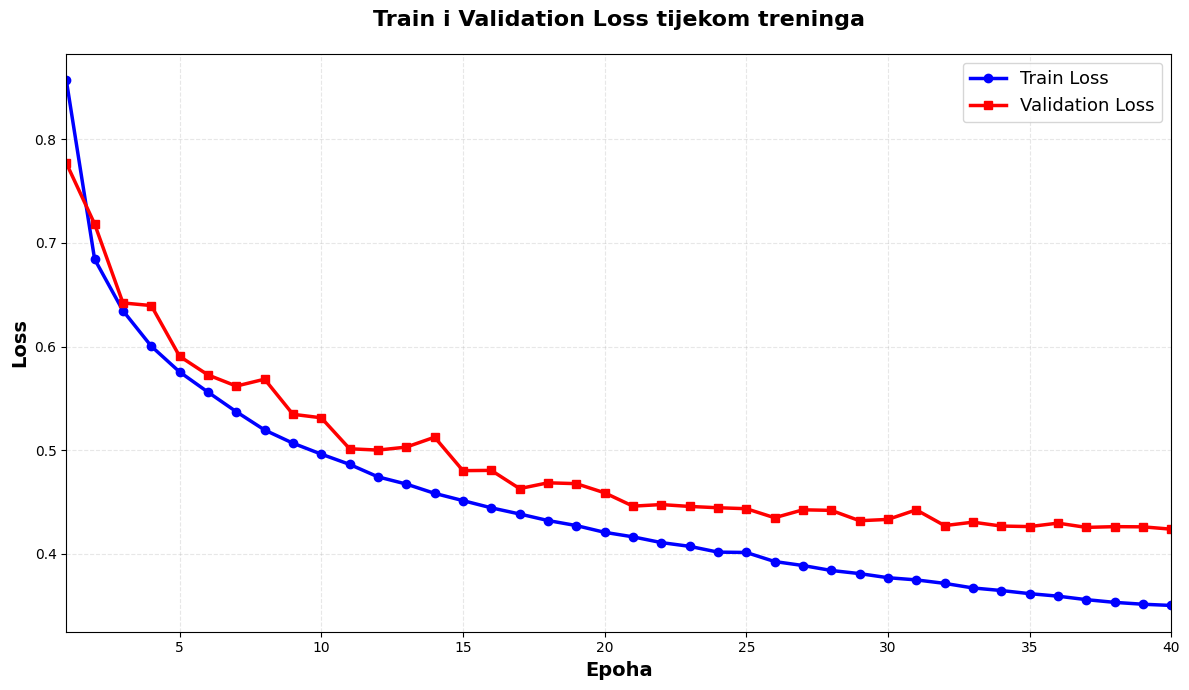

In [16]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, history['train_loss'], 'b-', linewidth=2.5, label='Train Loss', marker='o', markersize=6)
plt.plot(epochs, history['val_loss'], 'r-', linewidth=2.5, label='Validation Loss', marker='s', markersize=6)
plt.xlabel('Epoha', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')
plt.title('Train i Validation Loss tijekom treninga', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=13, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(1, len(epochs))
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'graf_01_loss_krivulje.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


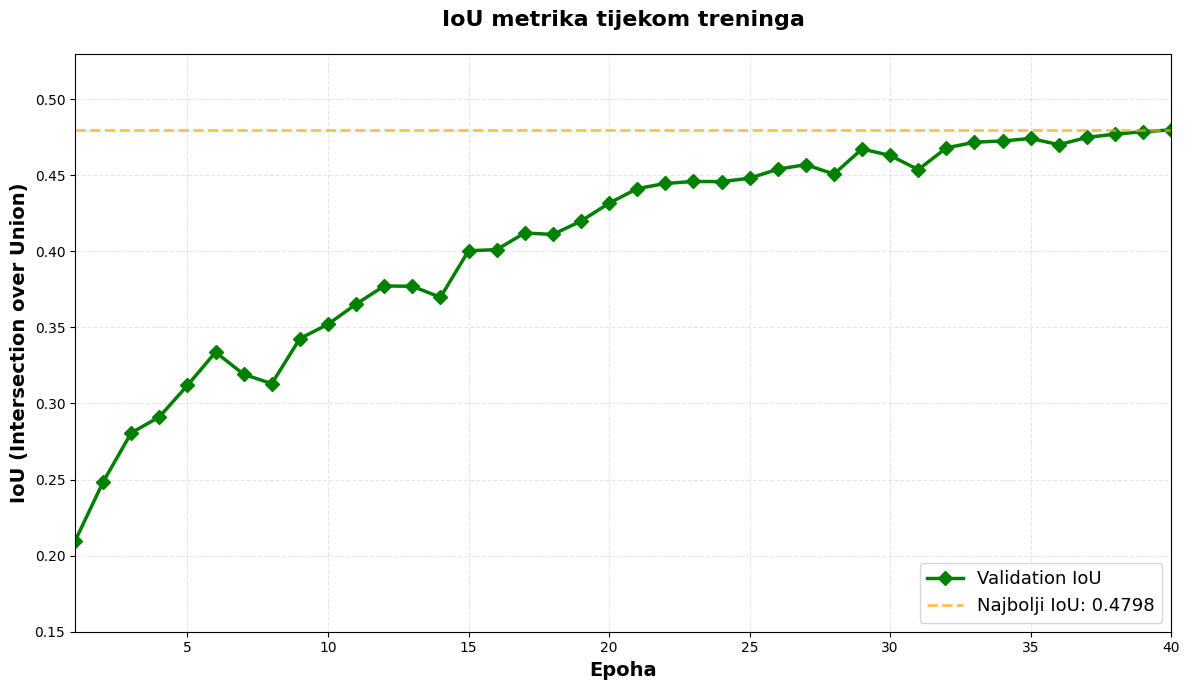

In [17]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, history['val_iou'], 'g-', linewidth=2.5, label='Validation IoU', marker='D', markersize=7)
plt.axhline(y=max(history['val_iou']), color='orange', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Najbolji IoU: {max(history["val_iou"]):.4f}')
plt.xlabel('Epoha', fontsize=14, fontweight='bold')
plt.ylabel('IoU (Intersection over Union)', fontsize=14, fontweight='bold')
plt.title('IoU metrika tijekom treninga', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=13, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(1, len(epochs))
plt.ylim(0.15, max(history['val_iou']) + 0.05)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'graf_02_iou_metrika.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

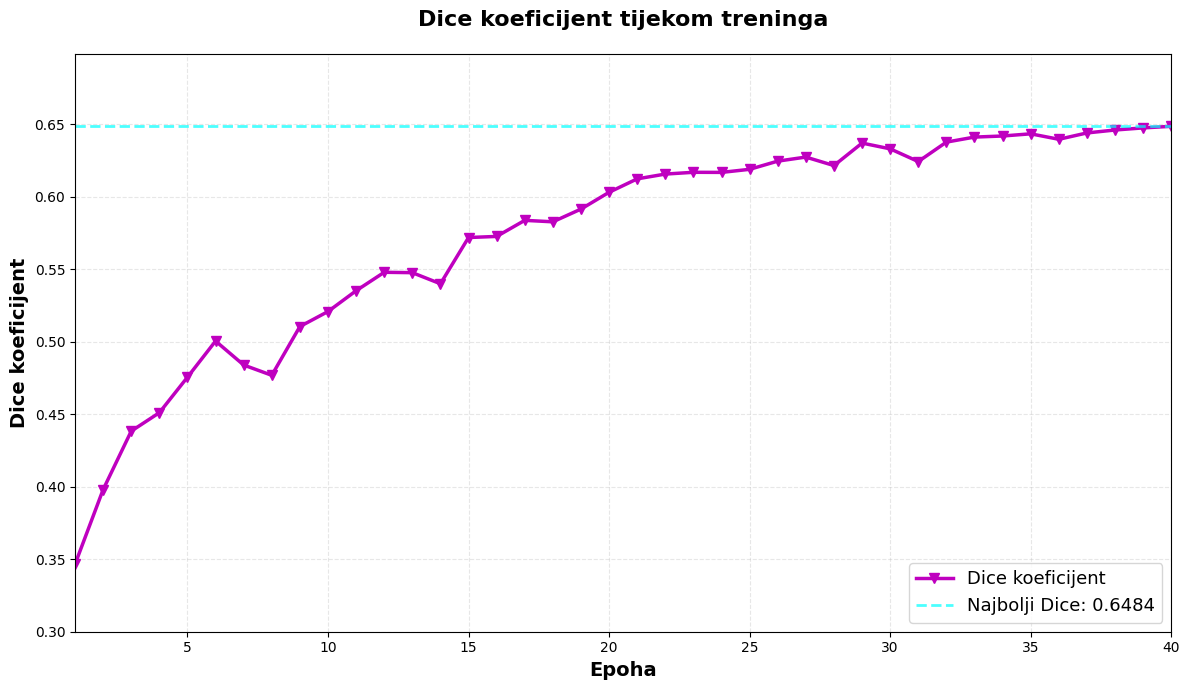

In [18]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, dice_scores, 'm-', linewidth=2.5, label='Dice koeficijent', marker='v', markersize=7)
plt.axhline(y=max(dice_scores), color='cyan', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Najbolji Dice: {max(dice_scores):.4f}')
plt.xlabel('Epoha', fontsize=14, fontweight='bold')
plt.ylabel('Dice koeficijent', fontsize=14, fontweight='bold')
plt.title('Dice koeficijent tijekom treninga', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=13, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(1, len(epochs))
plt.ylim(0.3, max(dice_scores) + 0.05)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'graf_03_dice_koeficijent.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

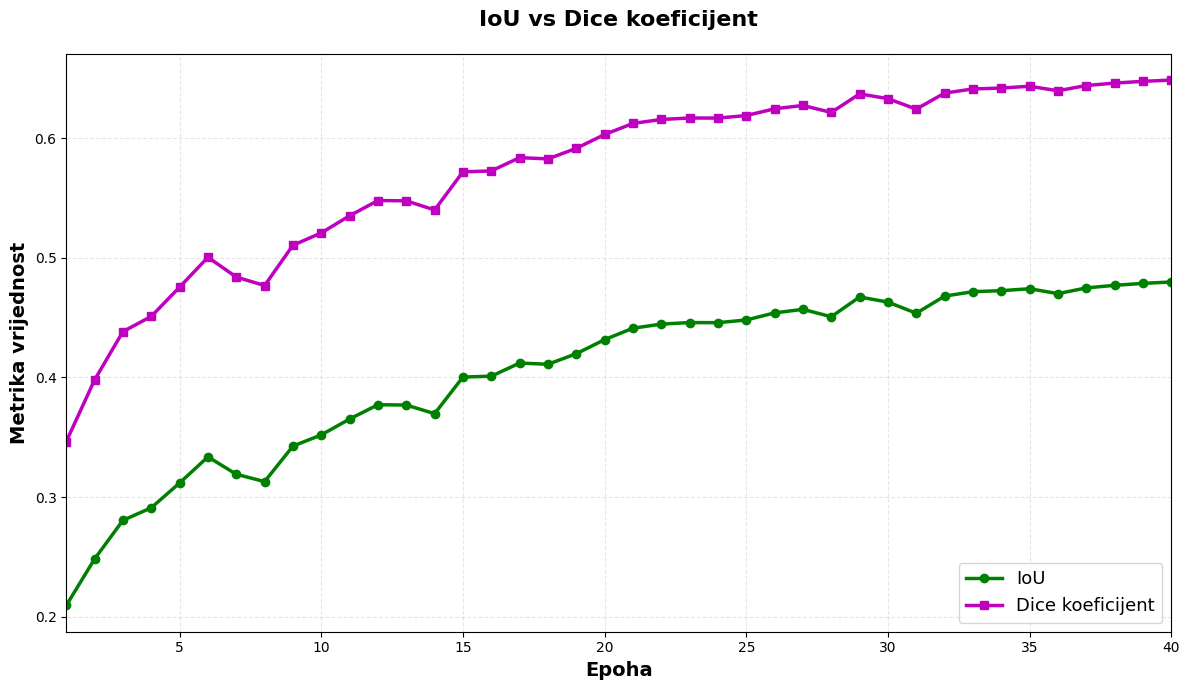

In [19]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, history['val_iou'], 'g-', linewidth=2.5, label='IoU', marker='o', markersize=6)
plt.plot(epochs, dice_scores, 'm-', linewidth=2.5, label='Dice koeficijent', marker='s', markersize=6)
plt.xlabel('Epoha', fontsize=14, fontweight='bold')
plt.ylabel('Metrika vrijednost', fontsize=14, fontweight='bold')
plt.title('IoU vs Dice koeficijent', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=13, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(1, len(epochs))
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'graf_04_iou_vs_dice.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

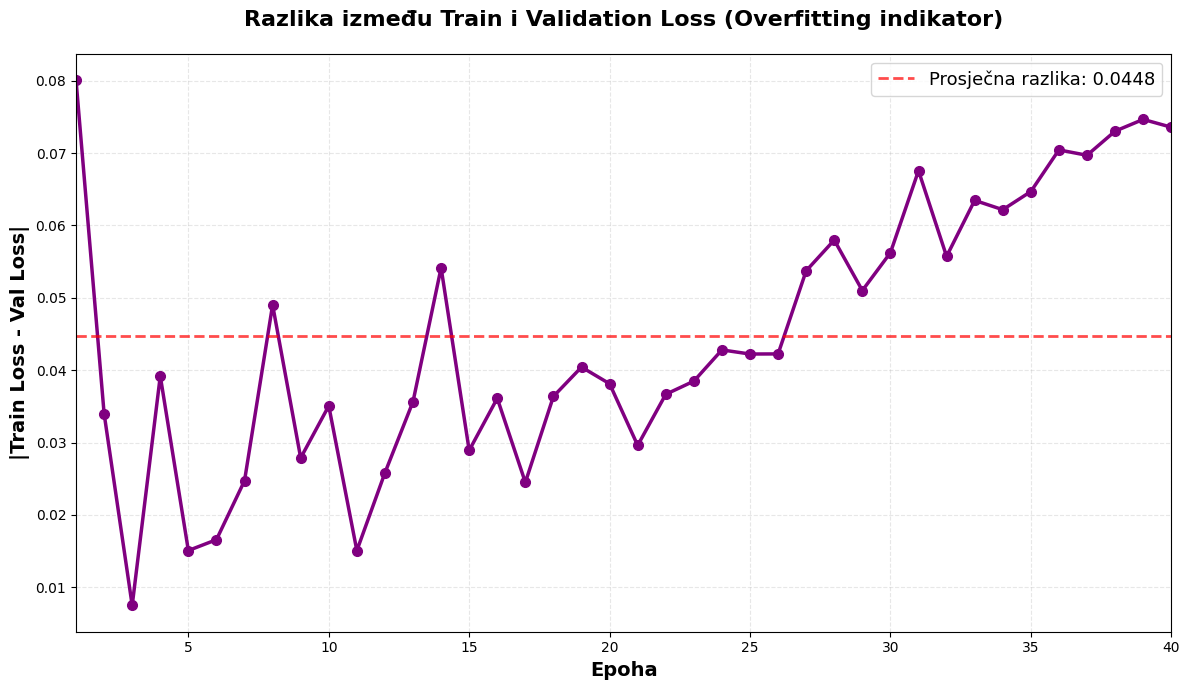

In [20]:
plt.figure(figsize=(12, 7))
loss_gap = [abs(t - v) for t, v in zip(history['train_loss'], history['val_loss'])]
plt.plot(epochs, loss_gap, 'purple', linewidth=2.5, marker='o', markersize=7)
plt.axhline(y=np.mean(loss_gap), color='red', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Prosječna razlika: {np.mean(loss_gap):.4f}')
plt.xlabel('Epoha', fontsize=14, fontweight='bold')
plt.ylabel('|Train Loss - Val Loss|', fontsize=14, fontweight='bold')
plt.title('Razlika između Train i Validation Loss (Overfitting indikator)',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=13)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(1, len(epochs))
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'graf_05_loss_gap.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

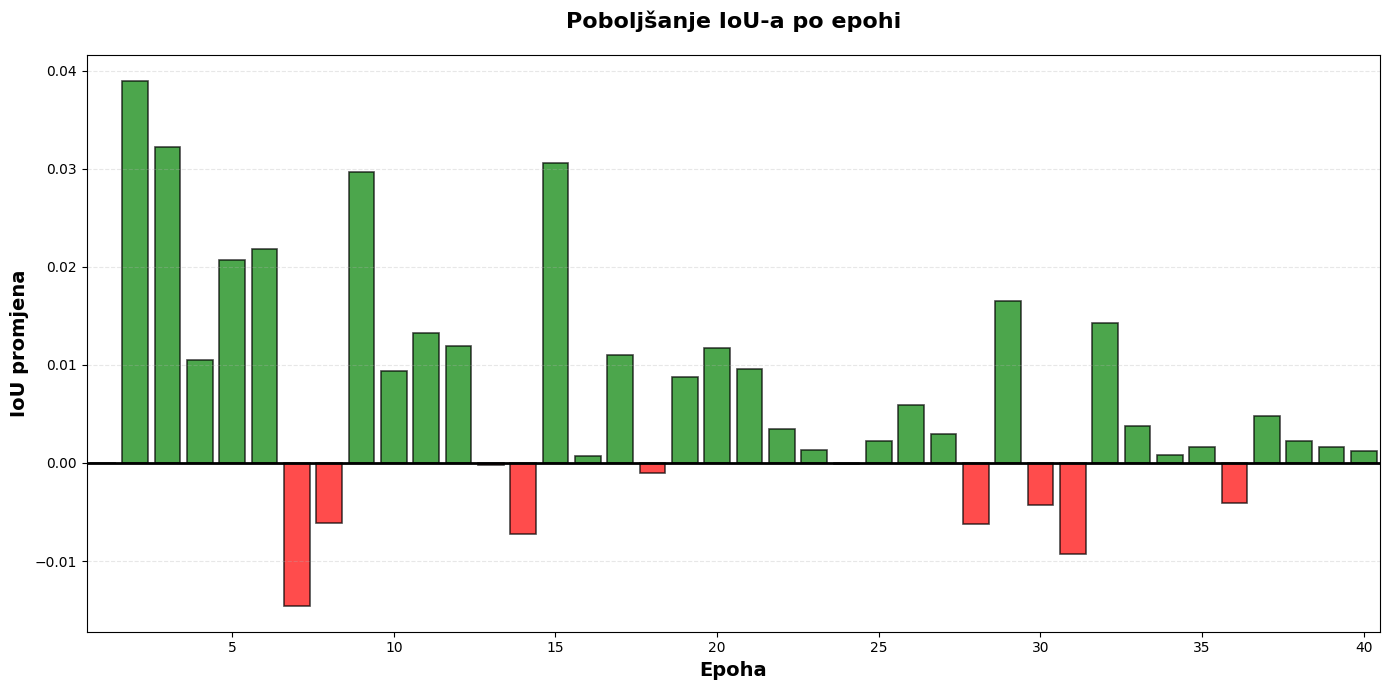

In [21]:
plt.figure(figsize=(14, 7))
iou_improvement = [0] + [(history['val_iou'][i] - history['val_iou'][i-1])
                          for i in range(1, len(history['val_iou']))]
colors = ['green' if x > 0 else 'red' for x in iou_improvement]
plt.bar(epochs, iou_improvement, color=colors, alpha=0.7, edgecolor='black', linewidth=1.2)
plt.xlabel('Epoha', fontsize=14, fontweight='bold')
plt.ylabel('IoU promjena', fontsize=14, fontweight='bold')
plt.title('Poboljšanje IoU-a po epohi', fontsize=16, fontweight='bold', pad=20)
plt.axhline(y=0, color='black', linewidth=2)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.xlim(0.5, len(epochs) + 0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'graf_06_iou_poboljsanje.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_path = '/content/drive/MyDrive/cityscapes/results'
os.makedirs(save_path, exist_ok=True)

In [23]:
# Boje
CITYSCAPES_COLORS = np.array([
    [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156], [190, 153, 153],
    [153, 153, 153], [250, 170, 30], [220, 220, 0], [107, 142, 35], [152, 251, 152],
    [70, 130, 180], [220, 20, 60], [255, 0, 0], [0, 0, 142], [0, 0, 70],
    [0, 60, 100], [0, 80, 100], [0, 0, 230], [119, 11, 32]
], dtype=np.uint8)

In [24]:
def colorize(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for cls in range(19):
        color_mask[mask == cls] = CITYSCAPES_COLORS[cls]
    return color_mask

In [25]:
model = UNet(num_classes=19).to(device)
checkpoint = torch.load(os.path.join(save_path, 'best_model.pth'), map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [26]:
idx = random.choice(range(len(val_ds)))
image, mask_gt = val_ds[idx]

In [27]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

In [28]:
with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

In [29]:
img_display = image.clone() * std + mean
img_display = img_display.permute(1, 2, 0).numpy()
img_display = np.clip(img_display, 0, 1)
mask_gt_np = mask_gt.cpu().numpy()

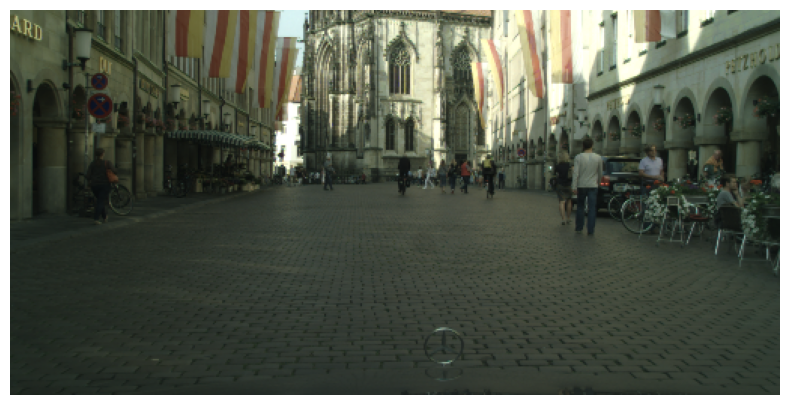

In [30]:
plt.figure(figsize=(10, 5))
plt.imshow(img_display)
plt.axis('off')
plt.savefig(os.path.join(save_path, f'val_img_{idx}_original.png'), bbox_inches='tight', pad_inches=0)
plt.show()

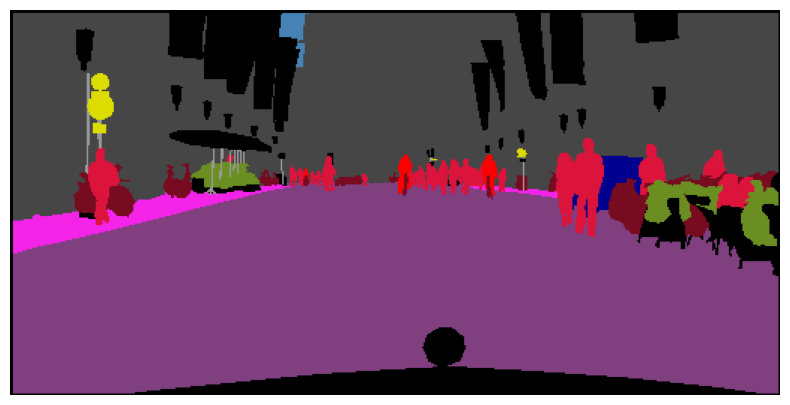

In [31]:
plt.figure(figsize=(10, 5))
plt.imshow(colorize(mask_gt_np))
plt.axis('off')
plt.savefig(os.path.join(save_path, f'val_img_{idx}_ground_truth.png'), bbox_inches='tight', pad_inches=0)
plt.show()

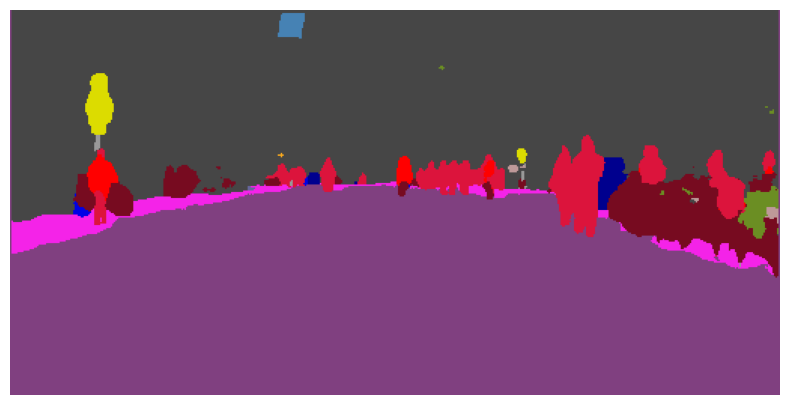

In [32]:
plt.figure(figsize=(10, 5))
plt.imshow(colorize(pred_mask))
plt.axis('off')
plt.savefig(os.path.join(save_path, f'val_img_{idx}_prediction.png'), bbox_inches='tight', pad_inches=0)
plt.show()

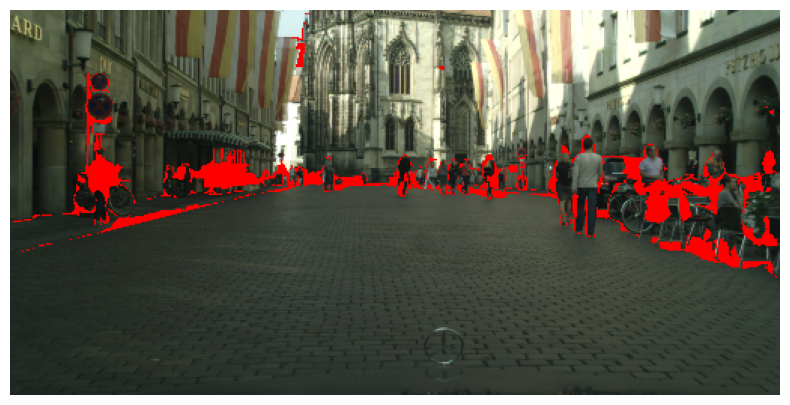

In [33]:
diff = (pred_mask != mask_gt_np) & (mask_gt_np != 255)
overlay = img_display.copy()
overlay[diff] = [1, 0, 0]

plt.figure(figsize=(10, 5))
plt.imshow(overlay)
plt.axis('off')
plt.savefig(os.path.join(save_path, f'val_img_{idx}_error.png'), bbox_inches='tight', pad_inches=0)
plt.show()